# Part II – Team 1: Step Change in Frequency

---

## 1. Introduction

In practical power systems, frequency deviations occur due to generation–load imbalance, load disturbances, or network events. Phasor Measurement Units (PMUs) estimate the fundamental phasor using a Discrete Fourier Transform (DFT) over a finite observation window.

The classical DFT-based phasor estimation assumes:

- The signal is stationary within the window.
- The signal frequency equals the nominal system frequency.

A sudden frequency step violates these assumptions, producing transient errors in magnitude and phase estimation.

This study analyzes the impact of a **step change in frequency** on:

- Sliding (Non-Recursive) DFT
- Recursive DFT
- Magnitude estimation
- Phase estimation
- Total Vector Error (TVE)
- Convergence behavior

---

## 2. Signal Model – Frequency Step with Multiple Harmonics

Nominal system frequency:

$$
f_0 = 50 \text{ Hz}
$$

At time $t_0$ (during the second cycle), the frequency steps to:

$$
f_1 = 51 \text{ Hz}
$$

To ensure phase continuity, the instantaneous phase is defined as:

$$
\Psi(t) = 2\pi \int_0^t f(\tau)\, d\tau + \phi_0
$$

For a step change at $t_0$:

$$
\Psi(t) =
\begin{cases}
2\pi f_0 t + \phi_0, & t < t_0 \\
\\
2\pi f_0 t_0 + 2\pi f_1 (t - t_0) + \phi_0, & t \ge t_0
\end{cases}
$$

The general signal containing DC and harmonic components is:

$$
v(t)
=
V_0
+
\sqrt{2}V_1 \cos(\Psi(t))
+
\sum_{n=2}^{N}
\sqrt{2}V_n
\cos\big(n\Psi(t) + \phi_n\big)
$$

where:

- $V_0$ = DC component  
- $V_1$ = RMS magnitude of fundamental  
- $V_n$ = RMS magnitude of the $n^{th}$ harmonic  
- $\phi_n$ = phase of the $n^{th}$ harmonic  

This model reflects realistic power system voltages that may contain harmonic distortion due to nonlinear loads or power electronic converters.

---

## 3. Instantaneous Phasor and Synchrophasor Definitions

### 3.1 Instantaneous Phasor

The instantaneous (true) phasor of the fundamental component is:

$$
V_{\text{inst}}(t) = V_1 e^{j\Psi(t)}
$$

This phasor directly tracks the actual signal frequency.

---

### 3.2 Synchrophasor (IEEE Reference)

In practical PMU applications, the synchrophasor is defined relative to the nominal frequency $f_0$.

The signal is written as:

$$
v(t) = \sqrt{2}V_1(t)\cos(2\pi f_0 t + \phi(t))
$$

where

$$
\phi(t) = 2\pi \int_0^t (f(\tau) - f_0)\, d\tau + \phi_0
$$

For a frequency step:

$$
\phi(t) =
\begin{cases}
\phi_0, & t < t_0 \\
\\
\phi_0 + 2\pi (f_1 - f_0)(t - t_0), & t \ge t_0
\end{cases}
$$

The synchrophasor is then:

$$
V(t) = V_1 e^{j\phi(t)}
$$

In this analysis, the exact phasor used for TVE comparison is consistent with the above formulation.

---

## 4. Sliding (Non-Recursive) DFT

The DFT-based phasor estimate over an $N$-sample window is:

$$
\hat{V}(k)
=
\frac{\sqrt{2}}{N}
\sum_{n=0}^{N-1}
v(k+n)
e^{-j \frac{2\pi}{N} n}
$$

At each time step:

- The window shifts by one sample.
- The complete summation is recomputed.

This method is exact but computationally expensive.

---

## 5. Recursive DFT

Using the window shift property, the recursive update rule is:

$$
\hat{V}_{k+1}
=
\left(
\hat{V}_k
+
\frac{\sqrt{2}}{N}
\left[
v(k+N) - v(k)
\right]
\right)
e^{j\frac{2\pi}{N}}
$$

The recursive formulation:

- Reduces computational burden.
- Produces results mathematically identical to the sliding DFT.
- Is suitable for real-time PMU implementation.

---

## 6. Effect of Frequency Step on Phasor Estimation

The DFT assumes:

$$
f(t) = f_0
$$

When the signal frequency changes:

$$
f_1 \neq f_0
$$

the observation window contains samples corresponding to two different frequencies.

This causes:

1. Loss of orthogonality between basis functions and signal components.
2. Spectral leakage.
3. Oscillatory magnitude behavior.
4. Phase drift in the estimated phasor.
5. Increased Total Vector Error (TVE).

---

### Effect of Harmonics Under Off-Nominal Frequency

Under nominal frequency, harmonics are orthogonal to the fundamental basis function in the DFT window.

When frequency deviates:

- Orthogonality is lost.
- Harmonic components introduce additional interference.
- Estimation error increases.
- TVE may slightly worsen compared to pure sinusoidal case.

Thus, harmonic content can influence convergence behavior during transients.

---

## 7. Convergence Behaviour

Let the window length correspond to one nominal cycle:

$$
T_w = \frac{1}{f_0}
$$

Immediately after disturbance:

- The window contains mixed 50 Hz and 51 Hz samples.
- The estimated phasor does not represent the new steady-state signal.

As time progresses:

- Pre-disturbance samples leave the window.
- Post-disturbance samples fill the window.

Convergence occurs when the window contains only post-disturbance samples.

Thus, the settling time satisfies approximately:

$$
T_w \lesssim T_{\text{settle}} \lesssim 1.5T_w
$$

The exact value depends on:

- The position of $t_0$ within the window.
- Harmonic content.
- Sampling rate.

---

## 8. Phase Drift After Frequency Step

Frequency deviation:

$$
\Delta f = f_1 - f_0
$$

Angular deviation:

$$
\Delta \omega = 2\pi (f_1 - f_0)
$$

After disturbance, the phase evolves as:

$$
\phi(t) =
\begin{cases}
\phi_0, & t < t_0 \\
\\
\phi_0 + 2\pi (f_1 - f_0)(t - t_0), & t \ge t_0
\end{cases}
$$

Thus, the synchrophasor exhibits linear phase drift relative to nominal frequency.

---

## 9. Total Vector Error (TVE)

TVE measures the accuracy of the estimated phasor:

$$
\text{TVE}(t)
=
\sqrt{
\frac{|V(t) - \hat{V}(t)|^2}{|V(t)|^2}
}
$$

Interpretation:

- TVE = 0 → Perfect estimation
- IEEE compliance typically requires:

$$
\text{TVE} < 1\%
$$

Immediately after the frequency step:

- TVE increases sharply.
- Oscillations appear.
- TVE gradually decreases as the window updates.

---

## 10. Comparison: Sliding vs Recursive DFT

| Feature | Sliding DFT | Recursive DFT |
|----------|------------|---------------|
| Computation | Full summation | Update equation |
| Computational Cost | High | Low |
| Accuracy | Exact | Exact |
| Convergence Behaviour | Identical | Identical |

Since the recursive equation is derived directly from the sliding DFT, both methods exhibit identical convergence and transient behavior.

---

## 11. Conclusion

A step change in frequency violates the constant-frequency assumption underlying DFT-based phasor estimation.

Key conclusions:

- Mixed-frequency samples within the observation window cause transient estimation error.
- Harmonic components increase interference under off-nominal conditions.
- Convergence time is approximately one window length.
- Recursive and non-recursive DFT exhibit identical dynamic behavior.
- TVE effectively quantifies transient estimation performance.

This analysis demonstrates the dynamic limitations of fixed-frequency DFT algorithms in power system monitoring under off-nominal operating conditions.

In [94]:
import numpy as np
import matplotlib.pyplot as plt

In [95]:
class Signal:
    def __init__(self, f1, f0, phi, ephi, tstart, tend, N=64, fs=50):
        self.f1 = f1
        self.f0 = f0
        self.phi = phi
        self.ephi = ephi
        self.tstart = tstart
        self.tend = tend
    # SIGNAL SAMPLING
        self.N = N
        self.fs = fs
        self.step_s = 1 / (self.N * self.fs)
        self.__t_s = np.arange(self.tstart, self.tend, self.step_s)
    # DEFINE YOUR SIGNAL CHARACTERISTICS HERE (AMPLITUDES, HARMONIC PHASES)
        self.V1 = 100 
        self.__y, self.__acc_phi = self.__genSignal(self.__t_s)
        self.__Vexact, self.__acc_ephi = self.__exactPhasor()
        
    def __genSignal(self, t):
        W = 2 * np.pi * self.f1 * (t - t[0]) + self.phi
        
        y = self.V1 * np.cos(W) # DEFINE YOUR FUNCTION HERE
        
        step = t[1] - t[0]
        phi_end  = 2 * np.pi * self.f1 * (t[-1] - t[0] + step) + self.phi
        return y, phi_end

    def __exactPhasor(self):
        t = self.__t_s
        phi_dev = 2 * np.pi * (self.f1 - self.f0) * (t - t[0]) + self.ephi

        step = t[1] - t[0]
        ephi_end = 2*np.pi*(self.f1-self.f0)*(t[-1]-t[0]+step) + self.ephi
        V = (self.V1/np.sqrt(2)) * np.exp(1j * phi_dev)
        return V, ephi_end

    def getValues(self):
        return self.__t_s, self.__y, self.__acc_phi, self.__acc_ephi, self.__Vexact

    def getPlot(self):
        step = 0.01e-3
        t_orig = np.arange(self.tstart,self.tend,step)
        y, _ = self.__genSignal(t_orig)
        
        plt.plot(t_orig,y,'blue','--',label = 'Original Signal',lw = 3)
        plt.plot(self.__t_s,self.__y,'ro',label = 'Sampled Points')
        plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Voltage (V)',fontsize=10)

In [96]:
class DFT:
    def __init__(self,y,N):
        self.y = y
        self.N = N
        self.__wndw = 0
        self.__W0 = 2 * np.pi / self.N
        self.__tot_wndw = self.y.size - self.N + 1

        self.C = self.__generateCoeff(self.__wndw)
        self.__cF = np.array([np.exp(-1j * self.__W0 * i) for i in range(self.__tot_wndw)])
    
    def __generateCoeff(self,W):
        mtrxDFT = (1/self.N) * np.array([[np.exp(-self.__W0*1j*col*row) for col in range(0,self.N)] for row in range(0,self.N)])
        dft_Ck = self.y[W:self.N+W]@mtrxDFT # Coefficients are calculated for W-th Window
        return dft_Ck
    
    def slide_dft(self,M):
        # M is the M-th Coefficient of the signal
        mtrxC_M = np.array([np.exp(-1j * self.__W0 * i * M) for i in range(0,self.N)])
        slide_raw =  (np.sqrt(2)/self.N) * np.array([self.y[i:(self.N + i)]@mtrxC_M for i in range(0,self.__tot_wndw)])
        slide_C = slide_raw * self.__cF
        return slide_C

    def recur_dft(self,M):
        recur_raw = np.zeros(self.__tot_wndw ,dtype=complex)
        mtrxC_M = np.array([np.exp(-1j * self.__W0 * i * M) for i in range(0,self.N)])
        
        phs_shft = np.exp(1j * self.__W0 * M)
        C1_0 = (np.sqrt(2)/self.N) * self.y[0:self.N]@mtrxC_M
        recur_raw[0] = C1_0
        for i in range(1,self.__tot_wndw):
            recur_raw[i] = (recur_raw[i-1] + (np.sqrt(2)/self.N) * (self.y[i+self.N-1] - self.y[i-1]))*phs_shft
        
        recur_C = recur_raw * self.__cF
        return recur_C

    def plotSpectrum(self):
        magnC = abs(self.C)
        phaseC = np.angle(self.C,deg = True)
        plt.stem(np.arange(0,self.N),magnCk)
        plt.title('DFT Magnitude Spectrum — Window {a}'.format(a = self.__wndw))
        plt.xlabel('Bin k'); plt.ylabel('Magnitude')
        plt.grid(); plt.show()
        
        plt.stem(np.arange(0,self.N),phaseCk)
        plt.title('DFT Phase Spectrum — Window {a}'.format(a = self.__wndw))
        plt.xlabel('Bin k'); plt.ylabel('Phase (°)')
        plt.grid(); plt.show()

    def computePhasor(self,M):
        phasor_C = np.sqrt(2) * self.C
        phsr_fnd = phasor_C[1]
        phsr_M = phasor_C[M]
        print("Fundamental Frequency Phasor - MAGN: {x}, PHASE: {z}".format(x = abs(phsr_fnd), z = np.angle(phsr_fnd, deg=True)))
        print("{a}th HARMONIC Phasor MAGN: {x}, PHASE: {z}".format(a = M, x = abs(phsr_M), z = np.angle(phsr_M, deg=True)))


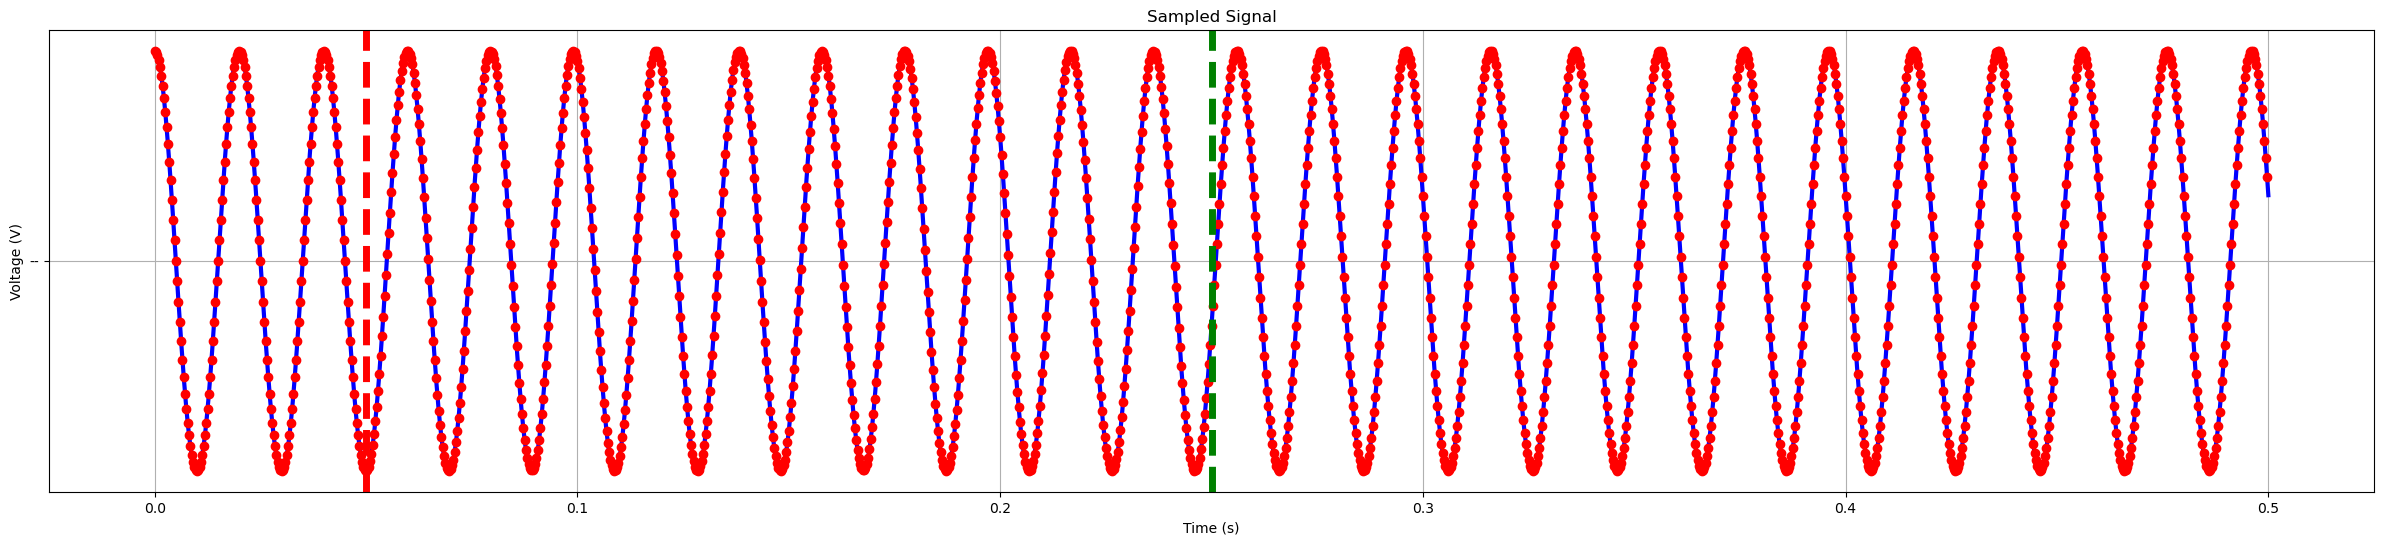

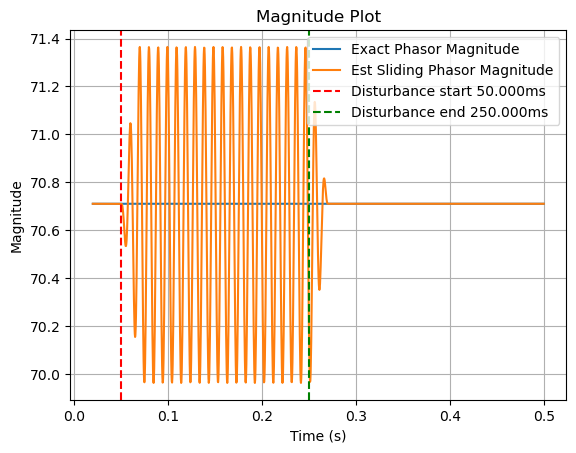

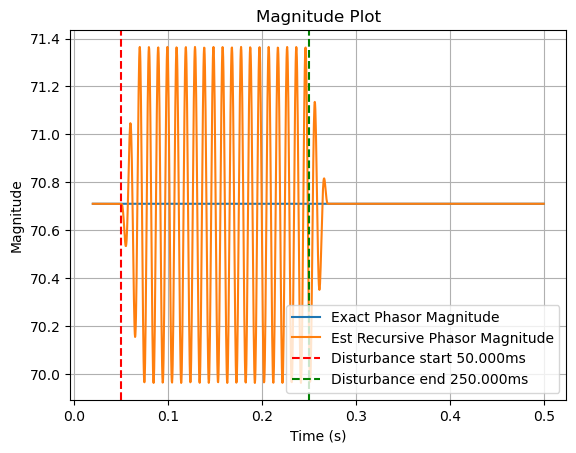

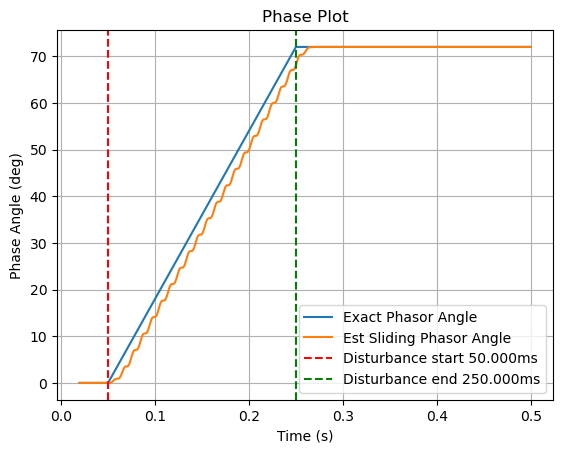

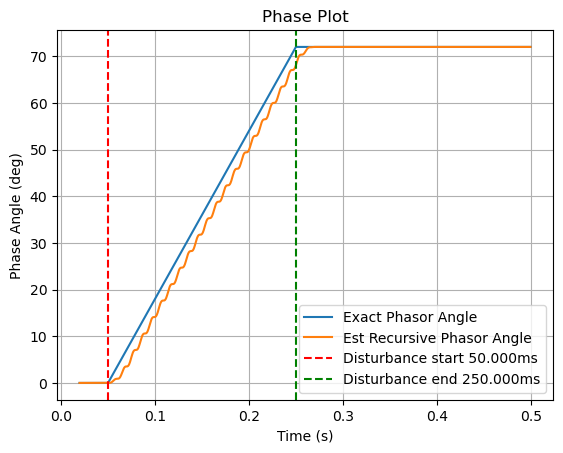

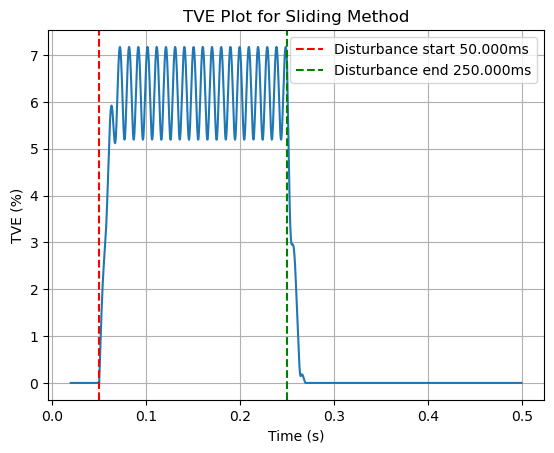

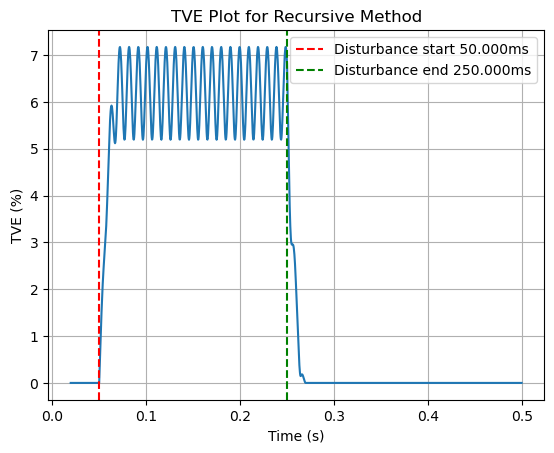

Convergence time for Non-Recursive Method:  0.26187499999999975
Convergence time for Recursive Method:  0.26187499999999975


In [99]:
f0 = 50; f1 = 51
td = 50e-3; tn = 250e-3; tsim = 500e-3
phi = 0
N = 64
fs = 50

seg1 = Signal(f0, f0, phi, 0, 0, td, N=64, fs=50)
t1, y1, phi1, ephi1, V1 = seg1.getValues()

seg2 = Signal(f1, f0, phi1, ephi1, td, tn, N=64, fs=50)
t2, y2, phi2, ephi2, V2 = seg2.getValues()

seg3 = Signal(f0, f0, phi2, ephi2, tn, tsim, N=64, fs=50)
t3, y3, _, _, V3 = seg3.getValues()

t_s    = np.hstack((t1, t2, t3))
y_s    = np.hstack((y1, y2, y3))
Vexact = np.hstack((V1, V2, V3))

plt.figure(figsize=(30, 6))
seg1.getPlot()
seg2.getPlot()
seg3.getPlot()
plt.axvline(td,  color='r', ls='--', lw=5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title("Sampled Signal")
plt.grid(); plt.show()

estPhsr = DFT(y_s,N)
estSlide_phsr = estPhsr.slide_dft(1)
estRecur_phsr = estPhsr.recur_dft(1)

V_match = Vexact[N-1::]
t_match = t_s[N-1::]

slide_TVE = (abs(V_match - estSlide_phsr) / abs(V_match)) * 100
recur_TVE = (abs(V_match - estRecur_phsr) / abs(V_match)) * 100

# PLOTTING
plt.plot(t_match,abs(V_match),label = "Exact Phasor Magnitude")
plt.plot(t_match,abs(estSlide_phsr),label = "Est Sliding Phasor Magnitude")
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('Magnitude Plot')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Magnitude',fontsize=10)
plt.grid(); plt.legend(); plt.show()

plt.plot(t_match,abs(V_match),label = "Exact Phasor Magnitude")
plt.plot(t_match,abs(estRecur_phsr),label = "Est Recursive Phasor Magnitude")
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('Magnitude Plot')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Magnitude',fontsize=10)
plt.grid(); plt.legend(); plt.show()

plt.plot(t_match,np.angle(V_match,deg=True), label = "Exact Phasor Angle")
plt.plot(t_match,np.angle(estSlide_phsr,deg=True), label = "Est Sliding Phasor Angle")
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('Phase Plot')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Phase Angle (deg)',fontsize=10)
plt.grid(); plt.legend(); plt.show()

plt.plot(t_match,np.angle(V_match,deg=True), label = "Exact Phasor Angle")
plt.plot(t_match,np.angle(estRecur_phsr,deg=True), label = "Est Recursive Phasor Angle")
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('Phase Plot')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Phase Angle (deg)',fontsize=10)
plt.grid(); plt.legend(); plt.show()

plt.plot(t_match,slide_TVE)
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('TVE Plot for Sliding Method')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('TVE (%)',fontsize=10)
plt.grid(); plt.legend(); plt.show()
plt.plot(t_match,recur_TVE)
plt.axvline(td,  color='r', ls='--', lw=1.5, label='Disturbance start {:0.3f}ms'.format(td*1e3))
plt.axvline(tn,  color='g', ls='--', lw=1.5, label='Disturbance end {:0.3f}ms'.format(tn*1e3))
plt.title('TVE Plot for Recursive Method')
plt.xlabel('Time (s)',fontsize=10); plt.ylabel('TVE (%)',fontsize=10)
plt.grid(); plt.legend(); plt.show()

t_c = t_match[(t_match>=tn) & (slide_TVE<1)][0]
print("Convergence time for Non-Recursive Method: ", t_c)
t_c = t_match[(t_match>=tn) & (recur_TVE<1)][0]
print("Convergence time for Recursive Method: ", t_c)

800


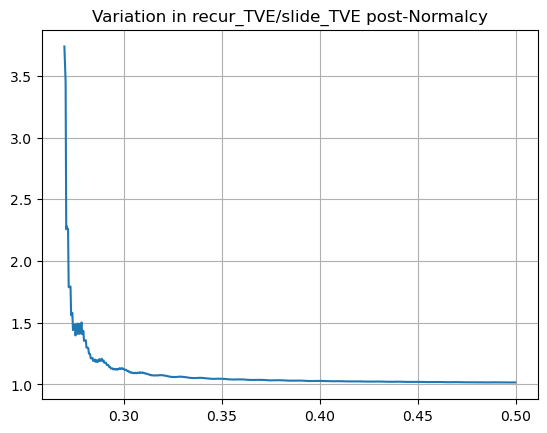

In [100]:
idx_tn = np.where(t_s >= tn)[0][0]
print(idx_tn)
factor = recur_TVE[idx_tn::] / slide_TVE[idx_tn::]

plt.plot(t_match[idx_tn : :],factor)
plt.title("Variation in recur_TVE/slide_TVE post-Normalcy")
plt.grid(); plt.show()